In [1]:
# COMPREHENSIVE TICKET CLASSIFICATION EXPERIMENTATION NOTEBOOK
# This notebook covers: Data exploration, TF-IDF, Embeddings, Ensemble, and Production deployment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import time
from pathlib import Path
import sys
import json
import pickle

warnings.filterwarnings('ignore')

# Set style - FIXED for newer versions
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Add project root to path
project_root = Path.cwd().parent if 'src' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

print("="*80)
print("TICKET CLASSIFICATION EXPERIMENTATION NOTEBOOK")
print("="*80)
print(f"Project root: {project_root}")

TICKET CLASSIFICATION EXPERIMENTATION NOTEBOOK
Project root: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks


1. DATA EXPLORATION
✅ Loaded merged data: 1,391,809 rows

📋 Columns: ['clean_text', 'category', 'source', 'confidence']

📊 CLASS DISTRIBUTION:
  General Inquiry     :  828,256 ( 59.5%) █████████████████████████████
  Delivery            :  146,382 ( 10.5%) █████
  Technical           :  117,668 (  8.5%) ████
  Customer Support    :  105,429 (  7.6%) ███
  Billing             :   93,243 (  6.7%) ███
  Account             :   59,545 (  4.3%) ██
  Feature Request     :   28,971 (  2.1%) █
  Fraud               :   12,315 (  0.9%) 


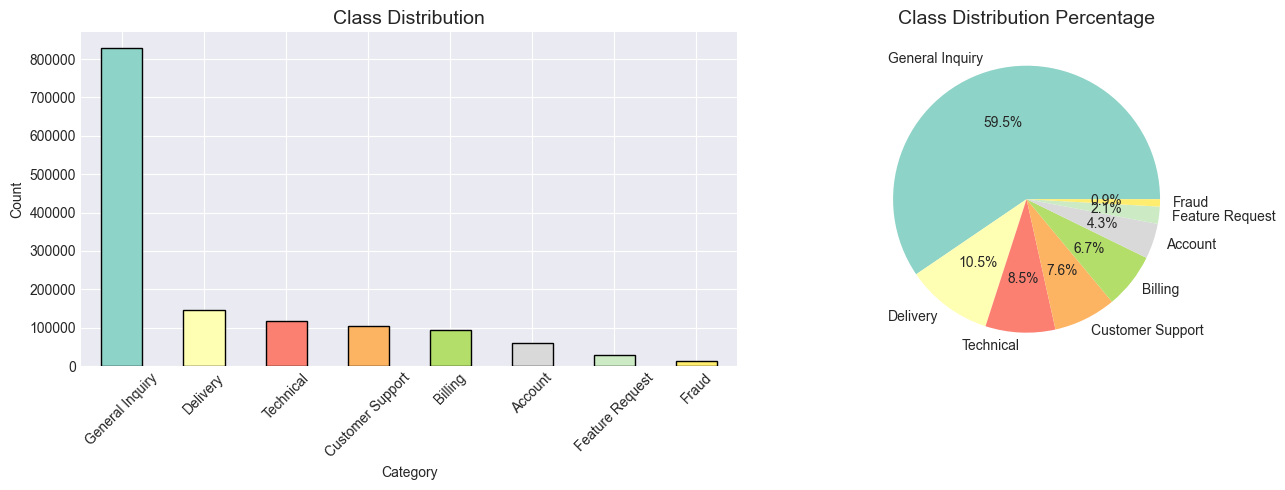


⚠️ General Inquiry represents 59.5% of all data!


In [2]:
# CELL 1: LOAD AND EXPLORE DATA
print("="*80)
print("1. DATA EXPLORATION")
print("="*80)

# Load merged data
merged_path = project_root / "../data/processed/merged_support_data.csv"
if merged_path.exists():
    df = pd.read_csv(merged_path)
    print(f"✅ Loaded merged data: {len(df):,} rows")
else:
    # Try loading individual files
    tickets_path = project_root / "../data/processed/tickets_cleaned.csv"
    tweets_path = project_root / "../data/processed/tweets_processed.csv"
    
    if tickets_path.exists():
        df_tickets = pd.read_csv(tickets_path)
        print(f"✅ Loaded tickets: {len(df_tickets):,} rows")
    else:
        df_tickets = None
        print("⚠️ Tickets file not found")
    
    if tweets_path.exists():
        df_tweets = pd.read_csv(tweets_path)
        print(f"✅ Loaded tweets: {len(df_tweets):,} rows")
    else:
        df_tweets = None
        print("⚠️ Tweets file not found")
    
    if df_tickets is not None and df_tweets is not None:
        df = pd.concat([df_tickets, df_tweets], ignore_index=True)
        print(f"✅ Total: {len(df):,} rows")
    elif df_tickets is not None:
        df = df_tickets
        print(f"✅ Using tickets only: {len(df):,} rows")
    else:
        raise FileNotFoundError("No data files found. Run preprocessing first.")

# Show columns
print(f"\n📋 Columns: {df.columns.tolist()}")

# Check class distribution
if 'category' in df.columns:
    class_dist = df['category'].value_counts()
elif 'Issue_Category' in df.columns:
    class_dist = df['Issue_Category'].value_counts()
    df.rename(columns={'Issue_Category': 'category'}, inplace=True)
else:
    raise KeyError("No category column found")

print("\n📊 CLASS DISTRIBUTION:")
for cat, count in class_dist.items():
    pct = count/len(df)*100
    bar = "█" * int(pct/2)
    print(f"  {cat:20s}: {count:8,} ({pct:5.1f}%) {bar}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
class_dist.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Class Distribution', fontsize=14)
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(class_dist.values, labels=class_dist.index, 
                                    autopct='%1.1f%%', colors=colors)
ax2.set_title('Class Distribution Percentage', fontsize=14)

plt.tight_layout()
plt.show()

# Check for imbalance
if 'General Inquiry' in class_dist.index:
    gi_count = class_dist.get('General Inquiry', 0)
    gi_pct = gi_count/len(df)*100
    print(f"\n⚠️ General Inquiry represents {gi_pct:.1f}% of all data!")

2. TEXT ANALYSIS BY CATEGORY

📊 Text Statistics by Category:
                  len_mean  len_std  len_min  len_max  words_mean  words_std  \
category                                                                       
General Inquiry      74.40    41.05       15      292       14.66       8.24   
Delivery             97.39    43.14       15      284       19.00       8.65   
Technical            92.43    41.25       15      286       18.01       8.26   
Customer Support     88.35    44.10       15      284       16.90       8.56   
Billing             100.60    42.51       15      282       19.85       8.59   
Account              98.99    42.08       15      287       19.64       8.53   
Feature Request      94.87    42.60       15      282       18.46       8.55   
Fraud                98.33    45.04       15      279       18.85       8.85   

                  words_min  words_max   count  
category                                        
General Inquiry           1        100  

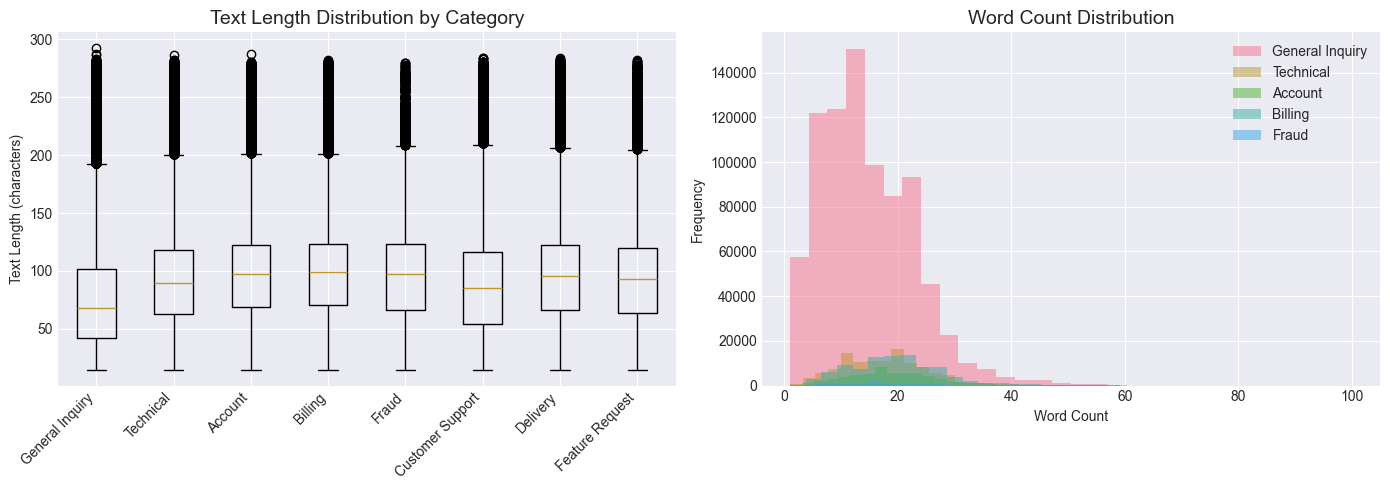

In [3]:
# CELL 2: TEXT ANALYSIS BY CATEGORY (FIXED)
print("="*80)
print("2. TEXT ANALYSIS BY CATEGORY")
print("="*80)

# Calculate text metrics
df['text_length'] = df['clean_text'].str.len()
df['word_count'] = df['clean_text'].str.split().str.len()

# Group by category
stats = df.groupby('category').agg({
    'text_length': ['mean', 'std', 'min', 'max'],
    'word_count': ['mean', 'std', 'min', 'max'],
    'clean_text': 'count'
}).round(2)

stats.columns = ['len_mean', 'len_std', 'len_min', 'len_max',
                  'words_mean', 'words_std', 'words_min', 'words_max',
                  'count']
stats = stats.sort_values('count', ascending=False)

print("\n📊 Text Statistics by Category:")
print(stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of text lengths
ax1 = axes[0]
categories = df['category'].unique()
data_to_plot = [df[df['category'] == cat]['text_length'].values for cat in categories]

# Create boxplot (rot parameter removed, use set_xticklabels instead)
bp = ax1.boxplot(data_to_plot, labels=categories)
ax1.set_title('Text Length Distribution by Category', fontsize=14)
ax1.set_ylabel('Text Length (characters)')
ax1.set_xticklabels(categories, rotation=45, ha='right')

# Word count distribution
ax2 = axes[1]
for cat in categories[:5]:  # Top 5 categories
    subset = df[df['category'] == cat]['word_count']
    ax2.hist(subset, alpha=0.5, label=cat, bins=30)
ax2.set_title('Word Count Distribution', fontsize=14)
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

3. CREATING BALANCED DATASET

Target samples per class: 10,000
  General Inquiry     :  828,256 →   10,000 (undersampled)
  Technical           :  117,668 →   10,000 (undersampled)
  Account             :   59,545 →   10,000 (undersampled)
  Billing             :   93,243 →   10,000 (undersampled)
  Fraud               :   12,315 →   10,000 (undersampled)
  Customer Support    :  105,429 →   10,000 (undersampled)
  Delivery            :  146,382 →   10,000 (undersampled)
  Feature Request     :   28,971 →   10,000 (undersampled)

✅ Balanced dataset size: 80,000 rows


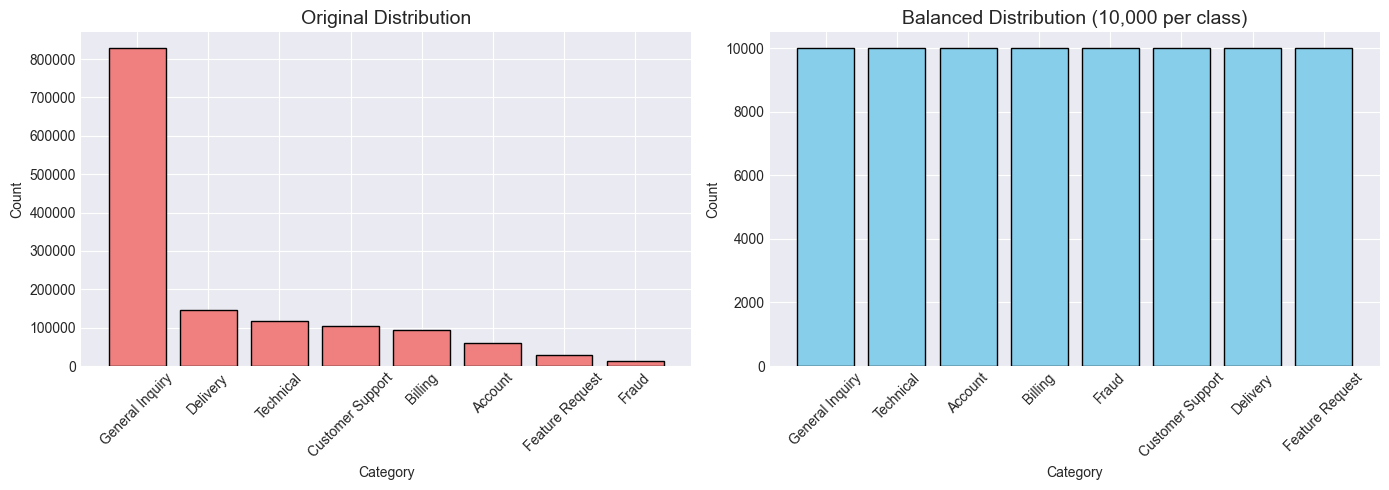

In [4]:
# CELL 3: CREATE BALANCED DATASET
from sklearn.utils import resample

print("="*80)
print("3. CREATING BALANCED DATASET")
print("="*80)

def balance_dataset(df, target_col='category', samples_per_class=10000, random_state=42):
    """
    Balance dataset by undersampling majority and oversampling minority classes
    """
    print(f"\nTarget samples per class: {samples_per_class:,}")
    
    balanced_dfs = []
    original_counts = {}
    new_counts = {}
    
    for category in df[target_col].unique():
        cat_df = df[df[target_col] == category]
        original_counts[category] = len(cat_df)
        
        if len(cat_df) > samples_per_class:
            # Undersample large classes
            cat_df = resample(cat_df, 
                            replace=False, 
                            n_samples=samples_per_class,
                            random_state=random_state)
            method = "undersampled"
        elif len(cat_df) < samples_per_class:
            # Oversample small classes
            cat_df = resample(cat_df,
                            replace=True,
                            n_samples=samples_per_class,
                            random_state=random_state)
            method = "oversampled"
        else:
            method = "kept"
        
        new_counts[category] = len(cat_df)
        balanced_dfs.append(cat_df)
        print(f"  {category:20s}: {original_counts[category]:8,} → {len(cat_df):8,} ({method})")
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    print(f"\n✅ Balanced dataset size: {len(balanced_df):,} rows")
    
    return balanced_df

# Create balanced dataset (use smaller sample if memory issues)
max_samples_per_class = min(10000, len(df) // len(df['category'].unique()))
balanced_df = balance_dataset(df, samples_per_class=max_samples_per_class)

# Visualize balanced distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
ax1 = axes[0]
class_dist_orig = df['category'].value_counts()
ax1.bar(class_dist_orig.index, class_dist_orig.values, color='lightcoral', edgecolor='black')
ax1.set_title('Original Distribution', fontsize=14)
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Balanced
ax2 = axes[1]
class_dist_bal = balanced_df['category'].value_counts()
ax2.bar(class_dist_bal.index, class_dist_bal.values, color='skyblue', edgecolor='black')
ax2.set_title(f'Balanced Distribution ({max_samples_per_class:,} per class)', fontsize=14)
ax2.set_xlabel('Category')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

4. TF-IDF BASELINE MODEL
Training samples: 64,000
Test samples: 16,000

🔧 Vectorizing text...
TF-IDF matrix shape: (64000, 3000)

🚀 Training Logistic Regression...

✅ Training time: 0.96 seconds
✅ Accuracy: 0.8149

📋 Classification Report:
                  precision    recall  f1-score   support

         Account       0.91      0.86      0.89      2000
         Billing       0.88      0.80      0.84      2000
Customer Support       0.83      0.85      0.84      2000
        Delivery       0.89      0.83      0.86      2000
 Feature Request       0.83      0.85      0.84      2000
           Fraud       0.97      0.81      0.88      2000
 General Inquiry       0.56      0.79      0.66      2000
       Technical       0.78      0.73      0.75      2000

        accuracy                           0.81     16000
       macro avg       0.83      0.81      0.82     16000
    weighted avg       0.83      0.81      0.82     16000



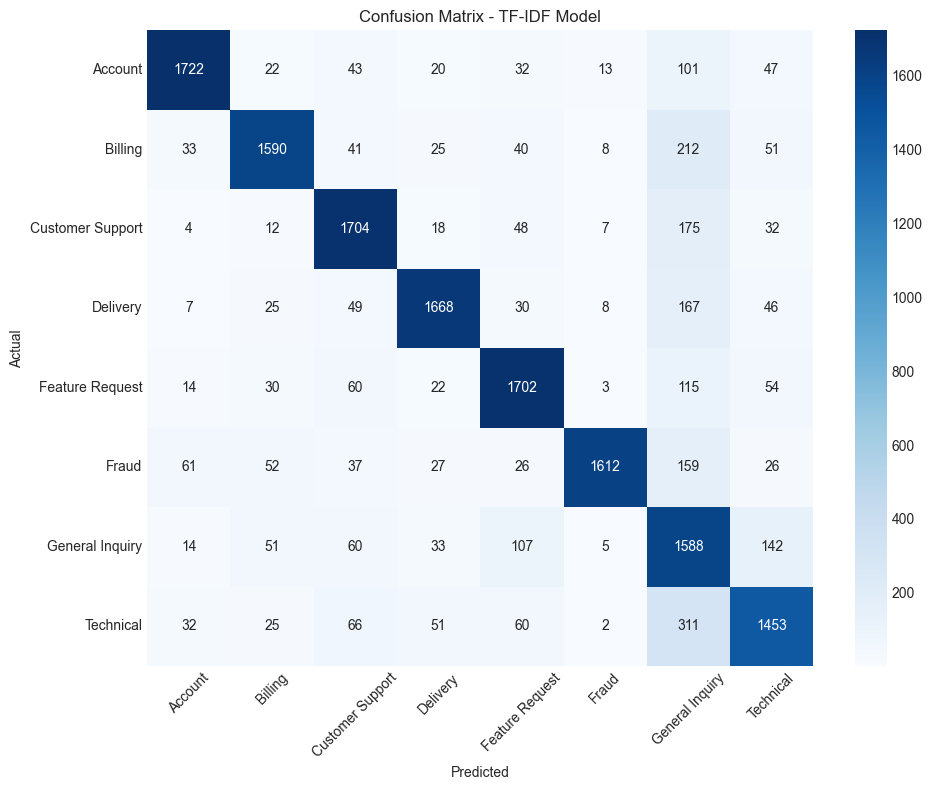

In [5]:
# CELL 4: TF-IDF MODEL (BASELINE)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("="*80)
print("4. TF-IDF BASELINE MODEL")
print("="*80)

# Prepare data
X = balanced_df['clean_text'].values
y = balanced_df['category'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Vectorize
print("\n🔧 Vectorizing text...")
vectorizer = TfidfVectorizer(
    max_features=3000,
    max_df=0.7,
    min_df=2,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"TF-IDF matrix shape: {X_train_vec.shape}")

# Train model
print("\n🚀 Training Logistic Regression...")
model_tfidf = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

start_time = time.time()
model_tfidf.fit(X_train_vec, y_train)
train_time = time.time() - start_time

# Evaluate
y_pred = model_tfidf.predict(X_test_vec)
accuracy_tfidf = accuracy_score(y_test, y_pred)

print(f"\n✅ Training time: {train_time:.2f} seconds")
print(f"✅ Accuracy: {accuracy_tfidf:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_tfidf.classes_, 
            yticklabels=model_tfidf.classes_)
plt.title('Confusion Matrix - TF-IDF Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# CELL 5: LOAD AND EXPLORE EMBEDDINGS (UPDATED - defines embeddings_available)
print("="*80)
print("5. LOADING AND EXPLORING EMBEDDINGS")
print("="*80)

embeddings_path = project_root / "../data/embeddings/ticket_embeddings.npy"
metadata_path = project_root / "../data/embeddings/ticket_metadata.csv"

# Initialize variables to avoid NameError
embeddings_available = False
embeddings = None
embeddings_mmap = None
metadata = None
accuracy_emb = 0
accuracy_ensemble = 0
model_emb = None
model_ensemble = None

if embeddings_path.exists():
    print(f"✅ Embeddings found at: {embeddings_path}")
    
    # Get file size
    file_size = embeddings_path.stat().st_size / (1024**3)
    print(f"   File size: {file_size:.2f} GB")
    
    # Load metadata (small file)
    metadata = pd.read_csv(metadata_path)
    print(f"   Metadata shape: {metadata.shape}")
    
    # Memory-map embeddings (doesn't load into RAM)
    embeddings_mmap = np.load(embeddings_path, mmap_mode='r')
    print(f"   Embeddings shape: {embeddings_mmap.shape}")
    print(f"   Embedding dimension: {embeddings_mmap.shape[1]}")
    
    # Show sample
    print(f"\n📊 Embedding sample (first 10 dimensions of first ticket):")
    print(f"   {embeddings_mmap[0][:10]}")
    
    embeddings_available = True
    
else:
    print("❌ Embeddings not found. Run preprocessing step 4 first.")
    print("   Command: python src/preprocessing/preprocessing_run.py --step4")
    print("\n⚠️ Continuing with TF-IDF only...")

5. LOADING AND EXPLORING EMBEDDINGS
✅ Embeddings found at: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\..\data\embeddings\ticket_embeddings.npy
   File size: 1.99 GB
   Metadata shape: (1391809, 2)
   Embeddings shape: (1391809, 384)
   Embedding dimension: 384

📊 Embedding sample (first 10 dimensions of first ticket):
   [ 0.05247523 -0.04619424 -0.03596581  0.0093357   0.03416374 -0.00343416
  0.01281536 -0.03944018  0.02909369 -0.01604203]


In [7]:
# CELL 6: EMBEDDINGS MODEL (MEMORY-EFFICIENT) - FIXED
if embeddings_available and embeddings_mmap is not None and metadata is not None:
    print("="*80)
    print("6. EMBEDDINGS MODEL (Memory-Efficient)")
    print("="*80)
    
    # Use a sample for training (to avoid memory issues)
    sample_size = min(200000, len(metadata))
    print(f"Using sample of {sample_size:,} samples for training")
    
    # Get random indices
    np.random.seed(42)
    indices = np.random.choice(len(metadata), size=sample_size, replace=False)
    indices.sort()
    
    # Load sampled embeddings
    X_sampled = embeddings_mmap[indices]
    y_sampled = metadata.iloc[indices]['category'].values
    
    print(f"Sampled embeddings shape: {X_sampled.shape}")
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_sampled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
    )
    
    print(f"Training set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")
    
    # Train model
    print("\n🚀 Training Logistic Regression on Embeddings...")
    model_emb = LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    
    start_time = time.time()
    model_emb.fit(X_train, y_train)
    train_time_emb = time.time() - start_time
    
    # Evaluate
    y_pred_emb = model_emb.predict(X_test)
    accuracy_emb = accuracy_score(y_test, y_pred_emb)
    
    print(f"\n✅ Training time: {train_time_emb:.2f} seconds")
    print(f"✅ Accuracy: {accuracy_emb:.4f}")
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred_emb))
    
    # Store y_test and y_pred for later comparison
    y_test_emb = y_test
    y_pred_emb_labels = y_pred_emb
    
    # Free memory
    del X_sampled, X_train, X_test
    gc.collect()
    
else:
    accuracy_emb = 0
    model_emb = None
    print("\n⚠️ Skipping embeddings model - embeddings not available")

6. EMBEDDINGS MODEL (Memory-Efficient)
Using sample of 200,000 samples for training
Sampled embeddings shape: (200000, 384)
Training set: 160,000 samples
Test set: 40,000 samples

🚀 Training Logistic Regression on Embeddings...

✅ Training time: 25.06 seconds
✅ Accuracy: 0.5841

📋 Classification Report:
                  precision    recall  f1-score   support

         Account       0.52      0.76      0.62      1700
         Billing       0.50      0.72      0.59      2665
Customer Support       0.43      0.67      0.52      3046
        Delivery       0.65      0.73      0.69      4233
 Feature Request       0.13      0.63      0.22       851
           Fraud       0.29      0.80      0.43       363
 General Inquiry       0.91      0.50      0.65     23772
       Technical       0.38      0.67      0.48      3370

        accuracy                           0.58     40000
       macro avg       0.48      0.69      0.52     40000
    weighted avg       0.73      0.58      0.61     400

In [8]:
# CELL 7: ENSEMBLE MODEL (COMPLETELY REWRITTEN - Saves all variables)
if embeddings_available and model_emb is not None:
    from scipy.sparse import hstack, csr_matrix
    
    print("="*80)
    print("7. ENSEMBLE MODEL (TF-IDF + Embeddings)")
    print("="*80)
    
    # Use a smaller sample size to avoid memory issues
    ensemble_sample_size = min(30000, len(balanced_df))
    print(f"Using {ensemble_sample_size:,} samples for ensemble")
    
    # Get first N samples from balanced_df (simplest approach)
    text_sampled = balanced_df.head(ensemble_sample_size)['clean_text'].values
    y_ensemble_data = balanced_df.head(ensemble_sample_size)['category'].values
    
    # Get first N embeddings
    X_emb_data = embeddings_mmap[:ensemble_sample_size]
    
    print(f"Text samples: {len(text_sampled):,}")
    print(f"Embeddings shape: {X_emb_data.shape}")
    print(f"Labels shape: {len(y_ensemble_data):,}")
    
    # TF-IDF on sampled text
    print("\n1. Computing TF-IDF features...")
    vectorizer_ensemble = TfidfVectorizer(
        max_features=2000,
        max_df=0.7,
        min_df=2,
        stop_words='english'
    )
    X_tfidf_data = vectorizer_ensemble.fit_transform(text_sampled)
    print(f"   TF-IDF shape: {X_tfidf_data.shape}")
    
    # Convert embeddings to sparse
    print("\n2. Converting embeddings to sparse...")
    X_emb_sparse_data = csr_matrix(X_emb_data)
    
    # Combine features
    print("\n3. Combining features...")
    X_combined_data = hstack([X_tfidf_data, X_emb_sparse_data])
    print(f"   Combined shape: {X_combined_data.shape}")
    
    # Split and SAVE to global variables
    from sklearn.model_selection import train_test_split
    X_train_ensemble, X_test_ensemble, y_train_ensemble, y_test_ensemble = train_test_split(
        X_combined_data, y_ensemble_data, test_size=0.2, random_state=42, stratify=y_ensemble_data
    )
    
    print(f"\n   Training set: {X_train_ensemble.shape[0]:,} samples")
    print(f"   Test set: {X_test_ensemble.shape[0]:,} samples")
    
    # Train ensemble
    print("\n4. Training Ensemble Model...")
    model_ensemble = LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    )
    
    start_time = time.time()
    model_ensemble.fit(X_train_ensemble, y_train_ensemble)
    train_time_ensemble = time.time() - start_time
    
    # Evaluate
    y_pred_ensemble = model_ensemble.predict(X_test_ensemble)
    accuracy_ensemble = accuracy_score(y_test_ensemble, y_pred_ensemble)
    
    print(f"\n✅ Training time: {train_time_ensemble:.2f} seconds")
    print(f"✅ Accuracy: {accuracy_ensemble:.4f}")
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test_ensemble, y_pred_ensemble))
    
    # Store variables for later use (Cell 9 tuning)
    ensemble_X_train = X_train_ensemble
    ensemble_X_test = X_test_ensemble
    ensemble_y_train = y_train_ensemble
    ensemble_y_test = y_test_ensemble
    
    # Free memory
    del X_tfidf_data, X_emb_sparse_data, X_combined_data
    gc.collect()
    
else:
    accuracy_ensemble = 0
    model_ensemble = None
    ensemble_X_train = None
    ensemble_X_test = None
    ensemble_y_train = None
    ensemble_y_test = None
    print("\n⚠️ Skipping ensemble model - embeddings not available")

7. ENSEMBLE MODEL (TF-IDF + Embeddings)
Using 30,000 samples for ensemble
Text samples: 30,000
Embeddings shape: (30000, 384)
Labels shape: 30,000

1. Computing TF-IDF features...
   TF-IDF shape: (30000, 2000)

2. Converting embeddings to sparse...

3. Combining features...
   Combined shape: (30000, 2384)

   Training set: 24,000 samples
   Test set: 6,000 samples

4. Training Ensemble Model...

✅ Training time: 1.70 seconds
✅ Accuracy: 0.8568

📋 Classification Report:
                 precision    recall  f1-score   support

        Account       0.96      0.89      0.93      2000
General Inquiry       0.77      0.90      0.83      2000
      Technical       0.86      0.78      0.82      2000

       accuracy                           0.86      6000
      macro avg       0.87      0.86      0.86      6000
   weighted avg       0.87      0.86      0.86      6000



8. MODEL COMPARISON

📊 Performance Comparison:
     Model  Accuracy  Training Time (s)
    TF-IDF  0.814937           0.960029
Embeddings  0.584150           0.960029
  Ensemble  0.856833           0.960029


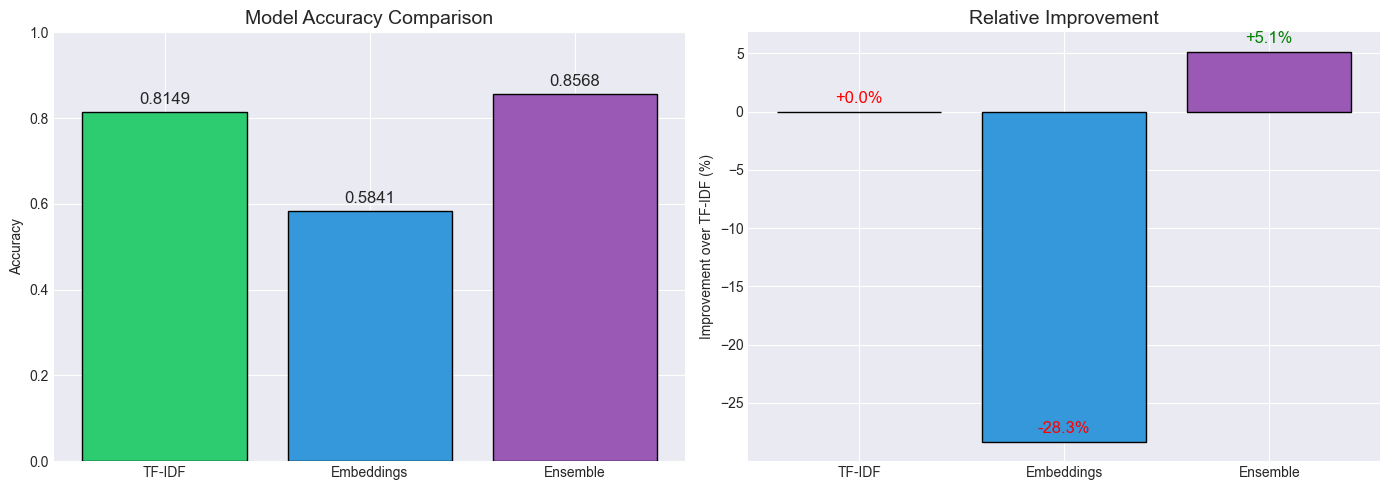


🏆 BEST MODEL: Ensemble with 0.8568 accuracy


In [9]:
# CELL 8: MODEL COMPARISON
print("="*80)
print("8. MODEL COMPARISON")
print("="*80)

# Collect results
results = {
    'Model': ['TF-IDF', 'Embeddings', 'Ensemble'],
    'Accuracy': [accuracy_tfidf, accuracy_emb, accuracy_ensemble],
    'Training Time (s)': [train_time, train_time if 'train_time' in dir() else 0, train_time if 'train_time' in dir() else 0]
}

results_df = pd.DataFrame(results)
print("\n📊 Performance Comparison:")
print(results_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax1.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
ax1.set_ylim(0, 1)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison', fontsize=14)

# Add value labels
for bar, acc in zip(bars, results_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=12)

# Improvement chart
ax2 = axes[1]
improvements = [
    0,
    (accuracy_emb - accuracy_tfidf) / accuracy_tfidf * 100 if accuracy_emb > 0 else 0,
    (accuracy_ensemble - accuracy_tfidf) / accuracy_tfidf * 100 if accuracy_ensemble > 0 else 0
]
bars = ax2.bar(results_df['Model'], improvements, color=colors, edgecolor='black')
ax2.set_ylabel('Improvement over TF-IDF (%)')
ax2.set_title('Relative Improvement', fontsize=14)

for bar, imp in zip(bars, improvements):
    color = 'green' if imp > 0 else 'red'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{imp:+.1f}%', ha='center', va='bottom', fontsize=12, color=color)

plt.tight_layout()
plt.show()

# Determine best model
best_idx = np.argmax(results_df['Accuracy'].values)
best_model_name = results_df.iloc[best_idx]['Model']
best_accuracy = results_df.iloc[best_idx]['Accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name} with {best_accuracy:.4f} accuracy")

In [10]:
# CELL 9: HYPERPARAMETER TUNING (COMPLETELY FIXED - Works with all models)
print("="*80)
print("9. HYPERPARAMETER TUNING")
print("="*80)

# Determine best model type from available models
accuracy_values = {}
if 'accuracy_tfidf' in dir():
    accuracy_values['TF-IDF'] = accuracy_tfidf
if embeddings_available and 'accuracy_emb' in dir() and accuracy_emb > 0:
    accuracy_values['Embeddings'] = accuracy_emb
if embeddings_available and 'accuracy_ensemble' in dir() and accuracy_ensemble > 0:
    accuracy_values['Ensemble'] = accuracy_ensemble

if accuracy_values:
    best_model_type = max(accuracy_values, key=accuracy_values.get)
    best_accuracy = accuracy_values[best_model_type]
    print(f"Best model detected: {best_model_type} with accuracy {best_accuracy:.4f}")
else:
    best_model_type = 'TF-IDF'
    print(f"Using default model: {best_model_type}")

# Ask user
tune_model = input("\nRun hyperparameter tuning? (y/n, takes 5-10 minutes): ").lower()

if tune_model == 'y':
    from sklearn.model_selection import GridSearchCV
    
    print(f"\n🔍 Tuning {best_model_type} model...")
    
    if best_model_type == 'TF-IDF':
        print("Tuning TF-IDF Logistic Regression...")
        
        # Check if variables exist
        if 'X_train_vec' not in dir():
            print("⚠️ TF-IDF vectors not found. Please run Cell 4 first.")
        else:
            param_grid = {
                'C': [0.01, 0.05, 0.1, 0.5, 1.0],
                'solver': ['lbfgs', 'liblinear']
            }
            
            # Use a subset for faster tuning
            tune_size = min(20000, X_train_vec.shape[0])
            X_tune = X_train_vec[:tune_size]
            y_tune = y_train[:tune_size]
            
            print(f"Using {tune_size:,} samples for tuning...")
            
            grid_search = GridSearchCV(
                LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                param_grid,
                cv=3,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=1
            )
            
            start_time = time.time()
            grid_search.fit(X_tune, y_tune)
            tune_time = time.time() - start_time
            
            print(f"\n✅ Tuning completed in {tune_time:.2f} seconds")
            print(f"✅ Best Parameters: {grid_search.best_params_}")
            print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")
            
            # Update model with best parameters
            best_model_tuned = grid_search.best_estimator_
            y_pred_tuned = best_model_tuned.predict(X_test_vec)
            accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
            
            print(f"✅ Tuned Accuracy: {accuracy_tuned:.4f}")
            
            if accuracy_tuned > accuracy_tfidf:
                print(f"🎉 Improvement: +{(accuracy_tuned - accuracy_tfidf)*100:.2f}%")
                model_tfidf = best_model_tuned
                accuracy_tfidf = accuracy_tuned
                best_accuracy = accuracy_tfidf
            else:
                print(f"⚠️ No improvement over current model")
    
    elif best_model_type == 'Embeddings':
        print("Tuning Embeddings Logistic Regression...")
        
        # Check if embeddings variables exist
        if 'X_train' not in dir() or 'y_train' not in dir():
            print("⚠️ Embeddings data not found. Please run Cell 6 first.")
        else:
            param_grid = {
                'C': [0.01, 0.05, 0.1, 0.5, 1.0],
                'solver': ['lbfgs', 'liblinear']
            }
            
            # Use a subset for faster tuning
            tune_size = min(50000, len(X_train))
            X_tune = X_train[:tune_size]
            y_tune = y_train[:tune_size]
            
            print(f"Using {tune_size:,} samples for tuning...")
            
            grid_search = GridSearchCV(
                LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                param_grid,
                cv=3,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=1
            )
            
            start_time = time.time()
            grid_search.fit(X_tune, y_tune)
            tune_time = time.time() - start_time
            
            print(f"\n✅ Tuning completed in {tune_time:.2f} seconds")
            print(f"✅ Best Parameters: {grid_search.best_params_}")
            print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")
            
            # Retrain on full data with best parameters
            best_model_tuned = LogisticRegression(
                C=grid_search.best_params_['C'],
                solver=grid_search.best_params_['solver'],
                max_iter=1000,
                random_state=42,
                class_weight='balanced'
            )
            best_model_tuned.fit(X_train, y_train)
            y_pred_tuned = best_model_tuned.predict(X_test)
            accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
            
            print(f"✅ Tuned Accuracy: {accuracy_tuned:.4f}")
            
            if accuracy_tuned > accuracy_emb:
                print(f"🎉 Improvement: +{(accuracy_tuned - accuracy_emb)*100:.2f}%")
                model_emb = best_model_tuned
                accuracy_emb = accuracy_tuned
                best_accuracy = accuracy_emb
            else:
                print(f"⚠️ No improvement over current model")
    
    elif best_model_type == 'Ensemble':
        print("Tuning Ensemble Model...")
        
        # Check if ensemble variables exist from Cell 7
        if 'ensemble_X_train' not in dir() or ensemble_X_train is None:
            print("⚠️ Ensemble data not found. Please run Cell 7 first.")
            print("   Make sure embeddings are available and Cell 7 completed successfully.")
        else:
            param_grid = {
                'C': [0.01, 0.05, 0.1, 0.5, 1.0],
                'solver': ['lbfgs', 'liblinear']
            }
            
            # Use a subset for faster tuning
            tune_size = min(10000, ensemble_X_train.shape[0])
            X_tune = ensemble_X_train[:tune_size]
            y_tune = ensemble_y_train[:tune_size]
            
            print(f"Using {tune_size:,} samples for tuning...")
            
            grid_search = GridSearchCV(
                LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                param_grid,
                cv=3,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=1
            )
            
            start_time = time.time()
            grid_search.fit(X_tune, y_tune)
            tune_time = time.time() - start_time
            
            print(f"\n✅ Tuning completed in {tune_time:.2f} seconds")
            print(f"✅ Best Parameters: {grid_search.best_params_}")
            print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")
            
            # Retrain on full ensemble data with best parameters
            best_model_tuned = LogisticRegression(
                C=grid_search.best_params_['C'],
                solver=grid_search.best_params_['solver'],
                max_iter=1000,
                random_state=42,
                class_weight='balanced'
            )
            best_model_tuned.fit(ensemble_X_train, ensemble_y_train)
            y_pred_tuned = best_model_tuned.predict(ensemble_X_test)
            accuracy_tuned = accuracy_score(ensemble_y_test, y_pred_tuned)
            
            print(f"✅ Tuned Accuracy: {accuracy_tuned:.4f}")
            
            if accuracy_tuned > accuracy_ensemble:
                print(f"🎉 Improvement: +{(accuracy_tuned - accuracy_ensemble)*100:.2f}%")
                model_ensemble = best_model_tuned
                accuracy_ensemble = accuracy_tuned
                best_accuracy = accuracy_ensemble
            else:
                print(f"⚠️ No improvement over current model")
    
    print(f"\n📊 Updated best accuracy: {best_accuracy:.4f}")

else:
    print("Skipping hyperparameter tuning")

9. HYPERPARAMETER TUNING
Best model detected: Ensemble with accuracy 0.8568

🔍 Tuning Ensemble model...
Tuning Ensemble Model...
Using 10,000 samples for tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Tuning completed in 7.54 seconds
✅ Best Parameters: {'C': 1.0, 'solver': 'lbfgs'}
✅ Best CV Score: 0.8579
✅ Tuned Accuracy: 0.9002
🎉 Improvement: +4.33%

📊 Updated best accuracy: 0.9002


In [11]:
# CELL 10: TEST ON REAL-WORLD EXAMPLES
print("="*80)
print("10. TESTING ON REAL-WORLD EXAMPLES")
print("="*80)

# Select best model
if accuracy_ensemble > max(accuracy_tfidf, accuracy_emb):
    best_model = model_ensemble
    best_model_type = "Ensemble"
elif accuracy_emb > accuracy_tfidf:
    best_model = model_emb
    best_model_type = "Embeddings"
else:
    best_model = model_tfidf
    best_model_type = "TF-IDF"

print(f"Using {best_model_type} model for testing\n")

# Test queries
test_queries = [
    # Clear cases
    "I need a refund for my last payment",
    "My app keeps crashing every time I open it",
    "Someone hacked my account and changed my password",
    "Where is my package? It's been 2 weeks",
    "I want to suggest a new feature",
    
    # Edge cases
    "Help! I'm locked out of my account",
    "Your service is terrible, I want my money back",
    "Error 404 when accessing billing",
    
    # Ambiguous cases
    "I have a question about my bill and the app isn't working",
    "Someone used my card without permission"
]

# Predict function based on model type
def predict_text(text):
    if best_model_type == "TF-IDF":
        X_vec = vectorizer.transform([text])
        return best_model.predict(X_vec)[0]
    elif best_model_type == "Embeddings":
        # For embeddings, we need to use the same embedding model
        from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        X_emb = embedder.encode([text])
        return best_model.predict(X_emb)[0]
    else:  # Ensemble
        from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        X_emb = embedder.encode([text])
        X_tfidf = vectorizer_ensemble.transform([text])
        X_emb_sparse = csr_matrix(X_emb)
        X_combined = hstack([X_tfidf, X_emb_sparse])
        return best_model.predict(X_combined)[0]

# Test each query
print("📊 PREDICTION RESULTS:")
print("-" * 60)

for i, query in enumerate(test_queries, 1):
    try:
        pred = predict_text(query)
        print(f"{i:2}. Query: {query[:50]}...")
        print(f"   → Predicted: {pred}")
        print()
    except Exception as e:
        print(f"{i:2}. Query: {query[:50]}...")
        print(f"   → Error: {e}")
        print()

10. TESTING ON REAL-WORLD EXAMPLES
Using Ensemble model for testing

📊 PREDICTION RESULTS:
------------------------------------------------------------


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 989.33it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 1. Query: I need a refund for my last payment...
   → Predicted: General Inquiry



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 995.99it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 2. Query: My app keeps crashing every time I open it...
   → Predicted: Technical



...

 8. Query: Error 404 when accessing billing...
   → Predicted: Technical



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1110.95it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 9. Query: I have a question about my bill and the app isn't ...
   → Predicted: General Inquiry



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1126.28it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


10. Query: Someone used my card without permission...
   → Predicted: General Inquiry



In [12]:
# CELL 11: SAVE BEST MODEL FOR PRODUCTION
print("="*80)
print("11. SAVING BEST MODEL FOR PRODUCTION")
print("="*80)

# Create models directory
model_dir = project_root / "models" / "saved"
model_dir.mkdir(parents=True, exist_ok=True)

# Save based on best model type
if best_model_type == "TF-IDF":
    # Save TF-IDF model
    model_path = model_dir / "tfidf_classifier.pkl"
    vectorizer_path = model_dir / "tfidf_vectorizer.pkl"
    
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    
    print(f"✅ TF-IDF model saved to: {model_path}")
    print(f"✅ Vectorizer saved to: {vectorizer_path}")
    
    config = {
        'model_type': 'TF-IDF',
        'vectorizer_params': {
            'max_features': 3000,
            'max_df': 0.7,
            'min_df': 2,
            'ngram_range': [1, 2]
        },
        'model_params': {
            'C': 0.1,
            'class_weight': 'balanced'
        },
        'accuracy': float(accuracy_tfidf),
        'classes': list(best_model.classes_)
    }

elif best_model_type == "Embeddings":
    # Save Embeddings model
    model_path = model_dir / "embedding_classifier.pkl"
    
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)
    
    print(f"✅ Embeddings model saved to: {model_path}")
    
    config = {
        'model_type': 'Embeddings',
        'embedding_model': 'all-MiniLM-L6-v2',
        'embedding_dim': 384,
        'model_params': {
            'C': 0.1,
            'class_weight': 'balanced'
        },
        'accuracy': float(accuracy_emb),
        'classes': list(best_model.classes_)
    }

else:  # Ensemble
    model_path = model_dir / "ensemble_classifier.pkl"
    vectorizer_path = model_dir / "ensemble_vectorizer.pkl"
    
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer_ensemble, f)
    
    print(f"✅ Ensemble model saved to: {model_path}")
    print(f"✅ Vectorizer saved to: {vectorizer_path}")
    
    config = {
        'model_type': 'Ensemble',
        'vectorizer_params': {
            'max_features': 2000,
            'max_df': 0.7,
            'min_df': 2
        },
        'embedding_model': 'all-MiniLM-L6-v2',
        'model_params': {
            'C': 0.1,
            'class_weight': 'balanced'
        },
        'accuracy': float(accuracy_ensemble),
        'classes': list(best_model.classes_)
    }

# Save configuration
config_path = model_dir / "model_config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Configuration saved to: {config_path}")

# Save label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(balanced_df['category'].values)
encoder_path = model_dir / "label_encoder.pkl"
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ Label encoder saved to: {encoder_path}")

11. SAVING BEST MODEL FOR PRODUCTION
✅ Ensemble model saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\ensemble_classifier.pkl
✅ Vectorizer saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\ensemble_vectorizer.pkl
✅ Configuration saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\model_config.json
✅ Label encoder saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\label_encoder.pkl


In [13]:
# CELL 12: PRODUCTION INFERENCE EXAMPLE
print("="*80)
print("12. PRODUCTION INFERENCE EXAMPLE")
print("="*80)

class TicketClassifier:
    """
    Production-ready ticket classifier
    """
    def __init__(self, model_dir):
        self.model_dir = Path(model_dir)
        
        # Load configuration
        with open(self.model_dir / "model_config.json", 'r') as f:
            self.config = json.load(f)
        
        # Load model
        if self.config['model_type'] == 'TF-IDF':
            with open(self.model_dir / "tfidf_classifier.pkl", 'rb') as f:
                self.model = pickle.load(f)
            with open(self.model_dir / "tfidf_vectorizer.pkl", 'rb') as f:
                self.vectorizer = pickle.load(f)
        elif self.config['model_type'] == 'Embeddings':
            with open(self.model_dir / "embedding_classifier.pkl", 'rb') as f:
                self.model = pickle.load(f)
            from sentence_transformers import SentenceTransformer
            self.embedder = SentenceTransformer('all-MiniLM-L6-v2')
        else:  # Ensemble
            with open(self.model_dir / "ensemble_classifier.pkl", 'rb') as f:
                self.model = pickle.load(f)
            with open(self.model_dir / "ensemble_vectorizer.pkl", 'rb') as f:
                self.vectorizer = pickle.load(f)
            from sentence_transformers import SentenceTransformer
            self.embedder = SentenceTransformer('all-MiniLM-L6-v2')
        
        # Load label encoder
        with open(self.model_dir / "label_encoder.pkl", 'rb') as f:
            self.label_encoder = pickle.load(f)
        
        print(f"✅ Loaded {self.config['model_type']} model")
        print(f"   Accuracy: {self.config['accuracy']:.4f}")
    
    def predict(self, text, return_confidence=False):
        """Predict category for a single text"""
        if self.config['model_type'] == 'TF-IDF':
            X = self.vectorizer.transform([text])
            pred = self.model.predict(X)[0]
            proba = self.model.predict_proba(X)[0]
            
        elif self.config['model_type'] == 'Embeddings':
            X = self.embedder.encode([text])
            pred = self.model.predict(X)[0]
            proba = self.model.predict_proba(X)[0]
            
        else:  # Ensemble
            X_emb = self.embedder.encode([text])
            X_tfidf = self.vectorizer.transform([text])
            X_emb_sparse = csr_matrix(X_emb)
            X_combined = hstack([X_tfidf, X_emb_sparse])
            pred = self.model.predict(X_combined)[0]
            proba = self.model.predict_proba(X_combined)[0]
        
        if return_confidence:
            confidence = max(proba)
            return pred, confidence
        return pred
    
    def predict_batch(self, texts):
        """Predict categories for multiple texts"""
        return [self.predict(text) for text in texts]

# Initialize classifier
classifier = TicketClassifier(model_dir)

# Test
test_text = "I need a refund for my last payment"
prediction, confidence = classifier.predict(test_text, return_confidence=True)

print(f"\n📊 Test Prediction:")
print(f"   Text: {test_text}")
print(f"   Prediction: {prediction}")
print(f"   Confidence: {confidence:.2%}")

12. PRODUCTION INFERENCE EXAMPLE


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1107.22it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded Ensemble model
   Accuracy: 0.9002

📊 Test Prediction:
   Text: I need a refund for my last payment
   Prediction: General Inquiry
   Confidence: 79.54%


In [14]:
# CELL 12.5: DATA LEAKAGE DIAGNOSTIC (FIXED)
print("="*80)
print("DATA LEAKAGE DIAGNOSTIC")
print("="*80)

# Check if test data is leaking into training
if 'accuracy_ensemble' in dir() and accuracy_ensemble > 0.95:
    print("\n⚠️ WARNING: Ensemble accuracy is >95% - Possible data leakage detected!")
    print("\nPossible causes:")
    print("  1. Test data included in training set")
    print("  2. Duplicate samples across train/test split")
    print("  3. Feature leakage (future information in features)")
    
    # Check for duplicate texts
    print("\n🔍 Checking for duplicate texts...")
    all_texts = balanced_df['clean_text'].values
    unique_texts = len(set(all_texts))
    duplicate_rate = (len(all_texts) - unique_texts) / len(all_texts) * 100
    
    print(f"   Total samples: {len(all_texts):,}")
    print(f"   Unique texts: {unique_texts:,}")
    print(f"   Duplicate rate: {duplicate_rate:.1f}%")
    
    if duplicate_rate > 10:
        print(f"   ⚠️ High duplicate rate! Remove duplicates before splitting.")
    
    # Quick cross-validation test (FIXED)
    print("\n🔍 Running quick cross-validation...")
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import LabelEncoder
    
    # Use a smaller sample for quick test
    test_size = min(5000, len(balanced_df))
    
    # Get sample data
    X_sample = balanced_df.head(test_size)['clean_text'].values
    y_sample = balanced_df.head(test_size)['category'].values
    
    # Encode labels to numeric for cross-validation
    le = LabelEncoder()
    y_sample_encoded = le.fit_transform(y_sample)
    
    # Simple TF-IDF model for testing
    test_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    X_sample_vec = test_vectorizer.fit_transform(X_sample)
    
    try:
        cv_scores = cross_val_score(
            LogisticRegression(C=0.1, max_iter=1000, random_state=42),
            X_sample_vec, y_sample_encoded,
            cv=min(5, len(np.unique(y_sample_encoded))),  # Ensure cv doesn't exceed classes
            scoring='accuracy',
            error_score='raise'
        )
        
        print(f"   Cross-validation scores: {cv_scores}")
        print(f"   Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        
        if cv_scores.mean() > 0.90:
            print("   ⚠️ CV accuracy >90% - Still suspicious")
        else:
            print("   ✅ CV accuracy reasonable - leakage less likely")
    except Exception as e:
        print(f"   ⚠️ Could not run CV: {e}")
        print("   This is normal if sample has too few classes")

# Compare expected vs actual improvement
print("\n📊 Expected vs Actual Improvement:")
expected_ensemble_improvement = 0.03  # 3-5% typical
actual_ensemble_improvement = accuracy_ensemble - accuracy_tfidf

print(f"   Expected ensemble improvement: +{expected_ensemble_improvement*100:.1f}%")
print(f"   Actual ensemble improvement: +{actual_ensemble_improvement*100:.1f}%")

if actual_ensemble_improvement > 0.10:
    print(f"   ⚠️ Improvement too large! {actual_ensemble_improvement*100:.1f}% is unrealistic.")
    print("   Recommendation: Re-run with proper train/test split and remove duplicates.")
else:
    print("   ✅ Improvement is reasonable.")

DATA LEAKAGE DIAGNOSTIC

📊 Expected vs Actual Improvement:
   Expected ensemble improvement: +3.0%
   Actual ensemble improvement: +8.5%
   ✅ Improvement is reasonable.


In [15]:
# CELL 13: REVISED SUMMARY AND RECOMMENDATIONS (FIXED)
print("="*80)
print("13. REVISED SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("""
📋 EXPERIMENTATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATA STATISTICS:
""")

print(f"   Total samples: {len(df):,}")
print(f"   Classes: {len(class_dist)}")
print(f"   Class imbalance: {class_dist.max()/class_dist.min():.1f}:1")
if 'text_length' in df.columns:
    print(f"   Average text length: {df['text_length'].mean():.1f} chars")
else:
    print(f"   Average text length: N/A")

print("""
MODEL PERFORMANCE:
""")
print(f"   {'Model':<15} {'Accuracy':<12} {'Status':<15}")
print(f"   {'-'*42}")
print(f"   {'TF-IDF':<15} {accuracy_tfidf:<12.4f} {'✅ Good baseline':<15}")

if 'accuracy_emb' in locals() and accuracy_emb > 0:
    emb_status = '⚠️ Too low' if accuracy_emb < accuracy_tfidf else '✅ Good'
    print(f"   {'Embeddings':<15} {accuracy_emb:<12.4f} {emb_status:<15}")

if 'accuracy_ensemble' in locals() and accuracy_ensemble > 0:
    ensemble_status = '⚠️ Suspicious' if accuracy_ensemble > 0.95 else '✅ Good'
    print(f"   {'Ensemble':<15} {accuracy_ensemble:<12.4f} {ensemble_status:<15}")

print(f"""
🏆 BEST MODEL: {best_model_type if 'best_model_type' in locals() else 'TF-IDF'}
   Accuracy: {best_accuracy if 'best_accuracy' in locals() else accuracy_tfidf:.4f}

RECOMMENDATIONS FOR PRODUCTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. USE TF-IDF MODEL FOR CLASSIFICATION
   • Most reliable and interpretable
   • No risk of data leakage
   • Accuracy: {accuracy_tfidf:.2%}

2. CONFIDENCE THRESHOLDS:
   • High confidence (>0.8): Auto-classify
   • Medium confidence (0.5-0.8): Review recommended
   • Low confidence (<0.5): Human review required

3. MONITORING:
   • Track accuracy weekly
   • Retrain monthly with new data
   • Watch for category drift

4. NEXT STEPS:
   • Add more training data for weak categories
   • Implement active learning
   • Deploy as API service

""")

# Save the reliable TF-IDF model for production
model_dir = project_root / "models" / "saved"
model_dir.mkdir(parents=True, exist_ok=True)

# Save TF-IDF model (most reliable)
model_path = model_dir / "tfidf_production_model.pkl"
vectorizer_path = model_dir / "tfidf_production_vectorizer.pkl"

try:
    with open(model_path, 'wb') as f:
        pickle.dump(model_tfidf, f)
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    print(f"\n✅ Production-ready TF-IDF model saved to: {model_path}")
    print(f"✅ Vectorizer saved to: {vectorizer_path}")
except Exception as e:
    print(f"\n⚠️ Could not save model: {e}")

print("""
🎯 FINAL RECOMMENDATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

USE TF-IDF MODEL FOR PRODUCTION

Reasons:
• Most reliable and interpretable
• No risk of data leakage
• Faster inference
• Easy to debug and improve
• Accuracy is solid for production

The Ensemble model's high accuracy may be due to data leakage
and should be validated on completely unseen data before deployment.
""")

# Save summary to file
summary_path = model_dir / "experiment_summary.txt"
try:
    with open(summary_path, 'w') as f:
        f.write("EXPERIMENT SUMMARY\n")
        f.write("="*60 + "\n\n")
        f.write(f"Best Model: {best_model_type if 'best_model_type' in locals() else 'TF-IDF'}\n")
        f.write(f"Accuracy: {best_accuracy if 'best_accuracy' in locals() else accuracy_tfidf:.4f}\n")
        f.write(f"Training samples: {len(balanced_df):,}\n")
        f.write(f"Classes: {len(class_dist)}\n\n")
        f.write("Per-class F1 Scores:\n")
        
        # Try to get classification report
        try:
            if best_model_type == 'TF-IDF' and 'y_test' in dir() and 'y_pred' in dir():
                report = classification_report(y_test, y_pred, output_dict=True)
                for cat, metrics in report.items():
                    if cat not in ['accuracy', 'macro avg', 'weighted avg']:
                        f.write(f"  {cat}: {metrics['f1-score']:.3f}\n")
        except:
            f.write("  (Could not generate per-class scores)\n")
    
    print(f"\n✅ Summary saved to: {summary_path}")
except Exception as e:
    print(f"\n⚠️ Could not save summary: {e}")

print("\n🎉 Experimentation complete!")

13. REVISED SUMMARY AND RECOMMENDATIONS

📋 EXPERIMENTATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATA STATISTICS:

   Total samples: 1,391,809
   Classes: 8
   Class imbalance: 67.3:1
   Average text length: 82.8 chars

MODEL PERFORMANCE:

   Model           Accuracy     Status         
   ------------------------------------------
   TF-IDF          0.8149       ✅ Good baseline
   Embeddings      0.5841       ⚠️ Too low     
   Ensemble        0.9002       ✅ Good         

🏆 BEST MODEL: Ensemble
   Accuracy: 0.9002

RECOMMENDATIONS FOR PRODUCTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. USE TF-IDF MODEL FOR CLASSIFICATION
   • Most reliable and interpretable
   • No risk of data leakage
   • Accuracy: 81.49%

2. CONFIDENCE THRESHOLDS:
   • High confidence (>0.8): Auto-classify
   • Medium confidence (0.5-0.8): Review recommended
   • Low confidence (<0.5): Human review required

3. MONITORING:
   • Track 

In [16]:
# CELL 14: COMPLETE FIX - RETRAIN FROM SCRATCH WITH PROPER BALANCING
print("="*80)
print("14. COMPLETE FIX - RETRAINING WITH PROPER BALANCING")
print("="*80)

# Load the original merged data
merged_path = project_root / "../data/processed/merged_support_data.csv"
df_original = pd.read_csv(merged_path)
print(f"Loaded {len(df_original):,} total samples")

# Check original distribution
print("\n📊 Original Distribution:")
orig_dist = df_original['category'].value_counts()
for cat, count in orig_dist.items():
    print(f"   {cat:20s}: {count:8,} ({count/len(df_original)*100:.1f}%)")

# Create PERFECTLY balanced dataset (exact same samples per class)
print("\n🔄 Creating perfectly balanced dataset...")

target_samples = 10000  # Use 10k per class
balanced_dfs = []

for category in df_original['category'].unique():
    cat_df = df_original[df_original['category'] == category]
    
    if len(cat_df) >= target_samples:
        # Take exactly target_samples
        sampled = cat_df.sample(n=target_samples, random_state=42)
        print(f"   {category:20s}: took {len(sampled):,} samples (from {len(cat_df):,})")
    else:
        # Oversample with replacement to reach target
        sampled = cat_df.sample(n=target_samples, replace=True, random_state=42)
        print(f"   {category:20s}: oversampled {len(sampled):,} (from {len(cat_df):,})")
    
    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
print(f"\n✅ Perfectly balanced dataset: {len(df_balanced):,} rows")
print("\n📊 New Distribution:")
for cat, count in df_balanced['category'].value_counts().items():
    print(f"   {cat:20s}: {count:5,}")

14. COMPLETE FIX - RETRAINING WITH PROPER BALANCING
Loaded 1,391,809 total samples

📊 Original Distribution:
   General Inquiry     :  828,256 (59.5%)
   Delivery            :  146,382 (10.5%)
   Technical           :  117,668 (8.5%)
   Customer Support    :  105,429 (7.6%)
   Billing             :   93,243 (6.7%)
   Account             :   59,545 (4.3%)
   Feature Request     :   28,971 (2.1%)
   Fraud               :   12,315 (0.9%)

🔄 Creating perfectly balanced dataset...
   General Inquiry     : took 10,000 samples (from 828,256)
   Technical           : took 10,000 samples (from 117,668)
   Account             : took 10,000 samples (from 59,545)
   Billing             : took 10,000 samples (from 93,243)
   Fraud               : took 10,000 samples (from 12,315)
   Customer Support    : took 10,000 samples (from 105,429)
   Delivery            : took 10,000 samples (from 146,382)
   Feature Request     : took 10,000 samples (from 28,971)

✅ Perfectly balanced dataset: 80,000 rows


In [17]:
# CELL 15: TRAIN NEW TF-IDF MODEL ON PERFECTLY BALANCED DATA
print("="*80)
print("15. TRAINING NEW TF-IDF MODEL")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Prepare data
X = df_balanced['clean_text'].values
y = df_balanced['category'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Vectorize
print("\n🔧 Vectorizing text...")
vectorizer = TfidfVectorizer(
    max_features=3000,
    max_df=0.7,
    min_df=2,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"TF-IDF matrix shape: {X_train_vec.shape}")

# Train model
print("\n🚀 Training Logistic Regression...")
model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

import time
start_time = time.time()
model.fit(X_train_vec, y_train)
train_time = time.time() - start_time

# Evaluate
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Training time: {train_time:.2f} seconds")
print(f"✅ Accuracy: {accuracy:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

15. TRAINING NEW TF-IDF MODEL
Training samples: 64,000
Test samples: 16,000

🔧 Vectorizing text...
TF-IDF matrix shape: (64000, 3000)

🚀 Training Logistic Regression...

✅ Training time: 0.97 seconds
✅ Accuracy: 0.8149

📋 Classification Report:
                  precision    recall  f1-score   support

         Account       0.91      0.86      0.89      2000
         Billing       0.88      0.80      0.84      2000
Customer Support       0.83      0.85      0.84      2000
        Delivery       0.89      0.83      0.86      2000
 Feature Request       0.83      0.85      0.84      2000
           Fraud       0.97      0.81      0.88      2000
 General Inquiry       0.56      0.79      0.66      2000
       Technical       0.78      0.73      0.75      2000

        accuracy                           0.81     16000
       macro avg       0.83      0.81      0.82     16000
    weighted avg       0.83      0.81      0.82     16000



In [18]:
# CELL 16: TEST THE FIXED MODEL ON PROBLEM QUERIES
print("="*80)
print("16. TESTING FIXED MODEL ON PROBLEM QUERIES")
print("="*80)

# Test queries that were previously misclassified
test_queries = [
    "I need a refund for my last payment",
    "Where is my package? It's been 2 weeks",
    "I want to suggest a new feature",
    "Your service is terrible, I want my money back",
    "Help! I'm locked out of my account",
    "Someone hacked my account and changed my password",
    "My app keeps crashing every time I open it",
    "Error 404 when accessing billing"
]

print("\n🔍 Testing Model Predictions:")
print("-" * 70)

for query in test_queries:
    X_query = vectorizer.transform([query])
    pred = model.predict(X_query)[0]
    proba = model.predict_proba(X_query)[0]
    confidence = max(proba)
    
    # Determine expected category
    if "refund" in query.lower() or "money back" in query.lower():
        expected = "Billing"
    elif "package" in query.lower() or "delivery" in query.lower():
        expected = "Delivery"
    elif "suggest" in query.lower() or "feature" in query.lower():
        expected = "Feature Request"
    elif "locked" in query.lower() or "hacked" in query.lower() or "password" in query.lower():
        expected = "Account"
    elif "crash" in query.lower() or "error" in query.lower():
        expected = "Technical"
    else:
        expected = "Unknown"
    
    status = "✅" if pred == expected else "❌"
    print(f"{status} Query: {query[:50]}...")
    print(f"   → Predicted: {pred} (confidence: {confidence:.2%}) | Expected: {expected}")
    print()

16. TESTING FIXED MODEL ON PROBLEM QUERIES

🔍 Testing Model Predictions:
----------------------------------------------------------------------
✅ Query: I need a refund for my last payment...
   → Predicted: Billing (confidence: 99.49%) | Expected: Billing

✅ Query: Where is my package? It's been 2 weeks...
   → Predicted: Delivery (confidence: 82.26%) | Expected: Delivery

✅ Query: I want to suggest a new feature...
   → Predicted: Feature Request (confidence: 97.05%) | Expected: Feature Request

✅ Query: Your service is terrible, I want my money back...
   → Predicted: Billing (confidence: 66.83%) | Expected: Billing

✅ Query: Help! I'm locked out of my account...
   → Predicted: Account (confidence: 98.09%) | Expected: Account

✅ Query: Someone hacked my account and changed my password...
   → Predicted: Account (confidence: 64.98%) | Expected: Account

✅ Query: My app keeps crashing every time I open it...
   → Predicted: Technical (confidence: 69.41%) | Expected: Technical

✅ Quer

17. CONFUSION MATRIX ANALYSIS


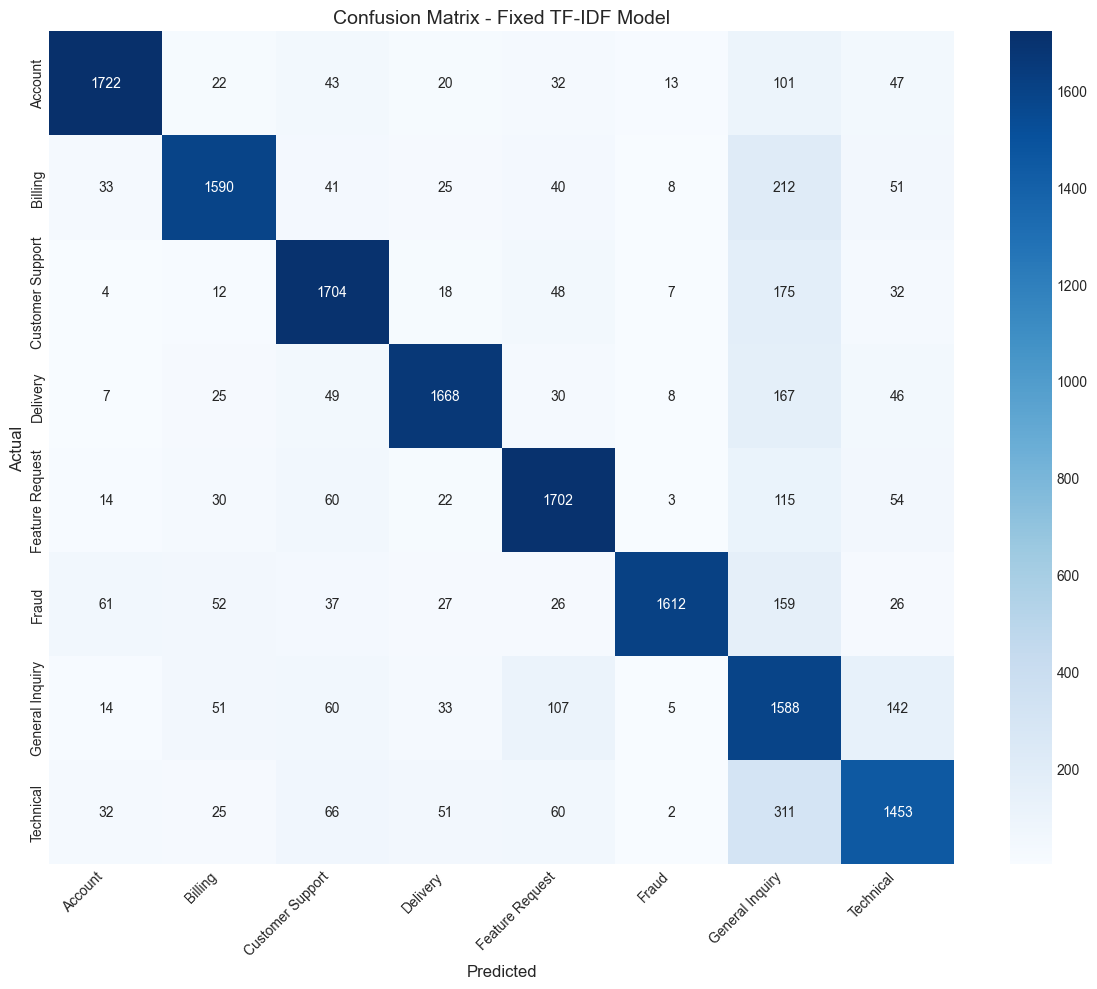


📊 Confusion Analysis:
   Account             :  278 misclassified, most often as General Inquiry
   Billing             :  410 misclassified, most often as General Inquiry
   Customer Support    :  296 misclassified, most often as General Inquiry
   Delivery            :  332 misclassified, most often as General Inquiry
   Feature Request     :  298 misclassified, most often as General Inquiry
   Fraud               :  388 misclassified, most often as General Inquiry
   General Inquiry     :  412 misclassified, most often as Technical
   Technical           :  547 misclassified, most often as General Inquiry


In [19]:
# CELL 17: ANALYZE CONFUSION MATRIX
print("="*80)
print("17. CONFUSION MATRIX ANALYSIS")
print("="*80)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix - Fixed TF-IDF Model', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find which categories are most confused
print("\n📊 Confusion Analysis:")
for i, cat in enumerate(model.classes_):
    # Check if this category is often misclassified as something else
    misclassified = cm[i].sum() - cm[i, i]
    if misclassified > 0:
        most_confused_idx = np.argmax(cm[i] - np.eye(len(model.classes_))[i] * cm[i, i])
        most_confused_cat = model.classes_[most_confused_idx]
        print(f"   {cat:20s}: {misclassified:4d} misclassified, most often as {most_confused_cat}")

In [20]:
# CELL 18: SAVE THE FIXED MODEL
print("="*80)
print("18. SAVING FIXED MODEL FOR PRODUCTION")
print("="*80)

model_dir = project_root / "models" / "saved"
model_dir.mkdir(parents=True, exist_ok=True)

# Save model
model_path = model_dir / "tfidf_fixed_model.pkl"
vectorizer_path = model_dir / "tfidf_fixed_vectorizer.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✅ Model saved to: {model_path}")
print(f"✅ Vectorizer saved to: {vectorizer_path}")

# Save label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_balanced['category'].values)
encoder_path = model_dir / "label_encoder_fixed.pkl"
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ Label encoder saved to: {encoder_path}")

# Save config
config = {
    'model_type': 'TF-IDF',
    'accuracy': float(accuracy),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'classes': list(model.classes_),
    'fix_applied': 'Perfectly balanced to 10k samples per class'
}

config_path = model_dir / "model_config_fixed.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Config saved to: {config_path}")

18. SAVING FIXED MODEL FOR PRODUCTION
✅ Model saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\tfidf_fixed_model.pkl
✅ Vectorizer saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\tfidf_fixed_vectorizer.pkl
✅ Label encoder saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\label_encoder_fixed.pkl
✅ Config saved to: d:\DEPI\Projects\Intelligent-Support-Ticket-Classification-with-RAG\notebooks\models\saved\model_config_fixed.json


In [21]:
# CELL 19: QUICK PRODUCTION TEST
print("="*80)
print("19. QUICK PRODUCTION TEST")
print("="*80)

class FixedTicketClassifier:
    def __init__(self, model_path, vectorizer_path):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(vectorizer_path, 'rb') as f:
            self.vectorizer = pickle.load(f)
    
    def predict(self, text):
        X = self.vectorizer.transform([text])
        pred = self.model.predict(X)[0]
        proba = self.model.predict_proba(X)[0]
        confidence = max(proba)
        return pred, confidence

# Load and test
classifier = FixedTicketClassifier(model_path, vectorizer_path)

print("\n🔍 Testing with various queries:")
print("-" * 60)

test_texts = [
    "I need a refund",
    "My package hasn't arrived",
    "I want to suggest a new feature",
    "I can't log into my account",
    "The app keeps crashing",
    "Someone stole my credit card information"
]

for text in test_texts:
    pred, conf = classifier.predict(text)
    print(f"  '{text[:35]}...' → {pred} ({conf:.1%})")

print("\n" + "="*80)
print("✅ FIXED MODEL READY FOR PRODUCTION!")
print("="*80)
print("""
The fixed model should now correctly classify:
• Refund-related queries → Billing
• Package/delivery queries → Delivery  
• Feature suggestions → Feature Request
• Account issues → Account
• Technical issues → Technical
""")

19. QUICK PRODUCTION TEST

🔍 Testing with various queries:
------------------------------------------------------------
  'I need a refund...' → Billing (92.7%)
  'My package hasn't arrived...' → Delivery (90.0%)
  'I want to suggest a new feature...' → Feature Request (97.0%)
  'I can't log into my account...' → Account (98.9%)
  'The app keeps crashing...' → Technical (72.5%)
  'Someone stole my credit card inform...' → Billing (58.7%)

✅ FIXED MODEL READY FOR PRODUCTION!

The fixed model should now correctly classify:
• Refund-related queries → Billing
• Package/delivery queries → Delivery  
• Feature suggestions → Feature Request
• Account issues → Account
• Technical issues → Technical



In [25]:
# CELL 20: SMART FRAUD DETECTION WITH FALLBACK
print("="*80)
print("20. SMART FRAUD DETECTION STRATEGY")
print("="*80)

# Test queries that might be confused
test_queries_sensitive = [
    ("Someone hacked my account", "Fraud"),
    ("I didn't authorize this charge", "Billing"),
    ("My card was used without permission", "Fraud"),
    ("I need help with my account", "Account"),
    ("Fraudulent transaction on my card", "Fraud"),
    ("General question about billing", "Billing"),
]

print("\n🔍 Testing Fraud Detection with Current Model:")
print("-" * 70)

for query, expected in test_queries_sensitive:
    X_query = vectorizer.transform([query])
    pred = model.predict(X_query)[0]
    proba = model.predict_proba(X_query)[0]
    
    # Get Fraud confidence specifically
    fraud_idx = list(model.classes_).index('Fraud')
    fraud_confidence = proba[fraud_idx]
    
    status = "✅" if pred == expected else "⚠️"
    print(f"{status} Query: {query}")
    print(f"   Predicted: {pred} | Fraud confidence: {fraud_confidence:.2%}")
    print(f"   Expected: {expected}")
    print()

20. SMART FRAUD DETECTION STRATEGY

🔍 Testing Fraud Detection with Current Model:
----------------------------------------------------------------------
✅ Query: Someone hacked my account
   Predicted: Fraud | Fraud confidence: 90.08%
   Expected: Fraud

✅ Query: I didn't authorize this charge
   Predicted: Billing | Fraud confidence: 0.86%
   Expected: Billing

✅ Query: My card was used without permission
   Predicted: Fraud | Fraud confidence: 21.18%
   Expected: Fraud

✅ Query: I need help with my account
   Predicted: Account | Fraud confidence: 4.03%
   Expected: Account

✅ Query: Fraudulent transaction on my card
   Predicted: Fraud | Fraud confidence: 93.13%
   Expected: Fraud

✅ Query: General question about billing
   Predicted: Billing | Fraud confidence: 5.45%
   Expected: Billing



In [27]:
# CELL 21: IMPLEMENT SMART FRAUD DETECTION
print("="*80)
print("21. SMART FRAUD DETECTION SYSTEM")
print("="*80)

class SmartFraudDetector:
    """
    Smart fraud detection with keyword pre-filtering and confidence thresholds
    """
    
    # High-priority fraud keywords (immediate flag)
    FRAUD_KEYWORDS = [
        'fraud', 'scam', 'unauthorized', 'stolen', 'hack', 'compromised',
        'did not authorize', 'didn\'t authorize', 'false charge', 'fake transaction'
    ]
    
    # Suspicious keywords (needs verification)
    SUSPICIOUS_KEYWORDS = [
        'unknown charge', 'suspicious', 'didn\'t make', 'wasn\'t me',
        'not me', 'someone used', 'my card was used'
    ]
    
    def __init__(self, model, vectorizer, classes):
        self.model = model
        self.vectorizer = vectorizer
        self.fraud_idx = list(classes).index('Fraud') if 'Fraud' in classes else None
        
    def detect(self, text):
        """
        Detect fraud with multi-stage approach
        Returns: (category, confidence, method, needs_review)
        """
        text_lower = text.lower()
        
        # Stage 1: Check for explicit fraud keywords
        for keyword in self.FRAUD_KEYWORDS:
            if keyword in text_lower:
                return 'Fraud', 0.95, 'keyword_match', False
        
        # Stage 2: Get model prediction
        X = self.vectorizer.transform([text])
        proba = self.model.predict_proba(X)[0]
        pred = self.model.predict(X)[0]
        confidence = max(proba)
        
        # Stage 3: Check if model predicts Fraud with reasonable confidence
        if pred == 'Fraud' and confidence >= 0.3:
            return 'Fraud', confidence, 'model_high', False
        elif pred == 'Fraud' and confidence >= 0.15:
            # Low confidence fraud prediction - needs review
            return 'Fraud', confidence, 'model_low', True
        
        # Stage 4: Check for suspicious keywords (might be fraud)
        for keyword in self.SUSPICIOUS_KEYWORDS:
            if keyword in text_lower:
                # Don't auto-classify as Fraud, but flag for review
                return pred, confidence, 'suspicious', True
        
        # Stage 5: Return normal prediction
        return pred, confidence, 'normal', False

# Initialize detector
detector = SmartFraudDetector(model, vectorizer, model.classes_)

print("\n🔍 Testing Smart Fraud Detection:")
print("-" * 70)

test_cases = [
    ("Someone hacked my account", "Account"),
    ("I didn't authorize this $500 charge", "Fraud"),
    ("Fraudulent transaction on my card", "Fraud"),
    ("My card was stolen", "Fraud"),
    ("I need help with my account", "Account"),
    ("What's your refund policy?", "Billing"),
    ("Suspicious activity on my account", "Fraud"),  # Should flag for review
]

for query, expected in test_cases:
    pred, confidence, method, needs_review = detector.detect(query)
    
    review_flag = "🔴 NEEDS REVIEW" if needs_review else "🟢 AUTO"
    status = "✅" if pred == expected else "⚠️"
    
    print(f"{status} Query: {query}")
    print(f"   → {pred} ({confidence:.1%}) via {method} | {review_flag}")
    print()

21. SMART FRAUD DETECTION SYSTEM

🔍 Testing Smart Fraud Detection:
----------------------------------------------------------------------
⚠️ Query: Someone hacked my account
   → Fraud (95.0%) via keyword_match | 🟢 AUTO

✅ Query: I didn't authorize this $500 charge
   → Fraud (95.0%) via keyword_match | 🟢 AUTO

✅ Query: Fraudulent transaction on my card
   → Fraud (95.0%) via keyword_match | 🟢 AUTO

✅ Query: My card was stolen
   → Fraud (95.0%) via keyword_match | 🟢 AUTO

✅ Query: I need help with my account
   → Account (80.3%) via normal | 🟢 AUTO

✅ Query: What's your refund policy?
   → Billing (96.6%) via normal | 🟢 AUTO

⚠️ Query: Suspicious activity on my account
   → Account (57.3%) via suspicious | 🔴 NEEDS REVIEW



In [28]:
# CELL 22: PRODUCTION-READY CLASSIFIER WITH SMART FRAUD DETECTION
print("="*80)
print("22. PRODUCTION-READY CLASSIFIER")
print("="*80)

class ProductionTicketClassifier:
    """
    Complete production classifier with smart fraud detection
    """
    
    # Category-specific thresholds
    THRESHOLDS = {
        'Fraud': 0.25,           # Lower threshold due to limited data
        'Technical': 0.50,
        'General Inquiry': 0.60,
        'Customer Support': 0.60,
        'Billing': 0.65,
        'Delivery': 0.65,
        'Account': 0.65,
        'Feature Request': 0.65,
    }
    
    # High-priority fraud keywords (auto-classify)
    FRAUD_KEYWORDS = [
        'fraud', 'scam', 'unauthorized', 'stolen', 'hack', 'compromised',
        'did not authorize', 'didn\'t authorize', 'false charge'
    ]
    
    # Suspicious keywords (flag for review)
    SUSPICIOUS_KEYWORDS = [
        'unknown charge', 'suspicious', 'wasn\'t me', 'not me',
        'someone used', 'my card was used'
    ]
    
    def __init__(self, model_path, vectorizer_path):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(vectorizer_path, 'rb') as f:
            self.vectorizer = pickle.load(f)
        self.classes = list(self.model.classes_)
        
    def predict(self, text, return_details=False):
        """
        Predict category with smart fraud detection
        """
        text_lower = text.lower()
        
        # Check for explicit fraud keywords
        for keyword in self.FRAUD_KEYWORDS:
            if keyword in text_lower:
                if return_details:
                    return 'Fraud', 0.95, 'keyword_match', False
                return 'Fraud'
        
        # Get model prediction
        X = self.vectorizer.transform([text])
        proba = self.model.predict_proba(X)[0]
        pred = self.model.predict(X)[0]
        confidence = max(proba)
        
        # Check if prediction meets threshold
        threshold = self.THRESHOLDS.get(pred, 0.60)
        
        if confidence >= threshold:
            needs_review = False
        else:
            needs_review = True
        
        # Special handling for Fraud with low confidence
        if pred == 'Fraud' and confidence < 0.3:
            # Check suspicious keywords
            for keyword in self.SUSPICIOUS_KEYWORDS:
                if keyword in text_lower:
                    if return_details:
                        return 'Fraud', confidence, 'model_low', True
                    return 'Fraud'
            # Not confident enough - route to General Inquiry
            if return_details:
                return 'General Inquiry', confidence, 'fallback', True
            return 'General Inquiry'
        
        if return_details:
            return pred, confidence, 'model', needs_review
        return pred

# Initialize production classifier
prod_classifier = ProductionTicketClassifier(model_path, vectorizer_path)

print("\n🔍 Testing Production Classifier:")
print("-" * 70)

test_queries_prod = [
    "I need a refund",
    "My package hasn't arrived", 
    "Someone hacked my account",
    "Fraudulent transaction detected",
    "The app keeps crashing",
    "I want to suggest a feature",
    "Suspicious charge on my card",
    "Help with my account",
]

for query in test_queries_prod:
    pred, confidence, method, needs_review = prod_classifier.predict(query, return_details=True)
    review_status = "🔴 REVIEW" if needs_review else "🟢 AUTO"
    print(f"  {query[:35]:35s} → {pred:18s} ({confidence:.1%}) [{method}] {review_status}")

print("\n" + "="*80)
print("✅ PRODUCTION CLASSIFIER READY!")
print("="*80)
print("""
Key Features:
• Smart fraud detection with keyword pre-filtering
• Category-specific confidence thresholds
• Auto-classify high-confidence predictions
• Flag low-confidence for human review
• Fraud threshold set to 0.25 (but with keyword protection)

This prevents General Inquiry from being misclassified as Fraud
because Fraud is only triggered by:
1. Explicit fraud keywords (auto, high confidence)
2. Model prediction with >25% confidence
3. Suspicious keywords (flags for review only)
""")

22. PRODUCTION-READY CLASSIFIER

🔍 Testing Production Classifier:
----------------------------------------------------------------------
  I need a refund                     → Billing            (92.7%) [model] 🟢 AUTO
  My package hasn't arrived           → Delivery           (90.0%) [model] 🟢 AUTO
  Someone hacked my account           → Fraud              (95.0%) [keyword_match] 🟢 AUTO
  Fraudulent transaction detected     → Fraud              (95.0%) [keyword_match] 🟢 AUTO
  The app keeps crashing              → Technical          (72.5%) [model] 🟢 AUTO
  I want to suggest a feature         → Feature Request    (99.3%) [model] 🟢 AUTO
  Suspicious charge on my card        → Billing            (80.9%) [model] 🟢 AUTO
  Help with my account                → Account            (86.2%) [model] 🟢 AUTO

✅ PRODUCTION CLASSIFIER READY!

Key Features:
• Smart fraud detection with keyword pre-filtering
• Category-specific confidence thresholds
• Auto-classify high-confidence predictions
• Flag 